In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
from tensorflow.keras.applications import ResNet50V2, EfficientNetB3, ResNet101V2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense, Input, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import AdamW # Or Adam
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from blue_blob_images_float import image_to_float
from plotting_random_images import plot_random_images
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess_input
from tensorflow.keras.applications.resnet_v2 import preprocess_input as resnet_preprocess_input
import os



In [2]:
from fine_tune import ModelFineTuner
from model_evaluator import ModelEvaluator

In [3]:
len(os.listdir("blueblobs_val")), len(os.listdir("galaxy_val")) 

(241, 306)

In [4]:
galaxies_images = image_to_float("galaxy_train")*255
galaxies_val_images = image_to_float("galaxy_val")*255

Attempting to load JPEG images from: galaxy_train using TensorFlow/Keras
Expecting images of size: (256, 256)
Found 680 items in the directory. Processing valid JPEGs...

------------------------------------
Image loading successful!
Loaded 680 images.
Final NumPy array shape: (680, 256, 256, 3)
Data type of array elements: uint8
------------------------------------
Attempting to load JPEG images from: galaxy_val using TensorFlow/Keras
Expecting images of size: (256, 256)
Found 306 items in the directory. Processing valid JPEGs...

------------------------------------
Image loading successful!
Loaded 306 images.
Final NumPy array shape: (306, 256, 256, 3)
Data type of array elements: uint8
------------------------------------


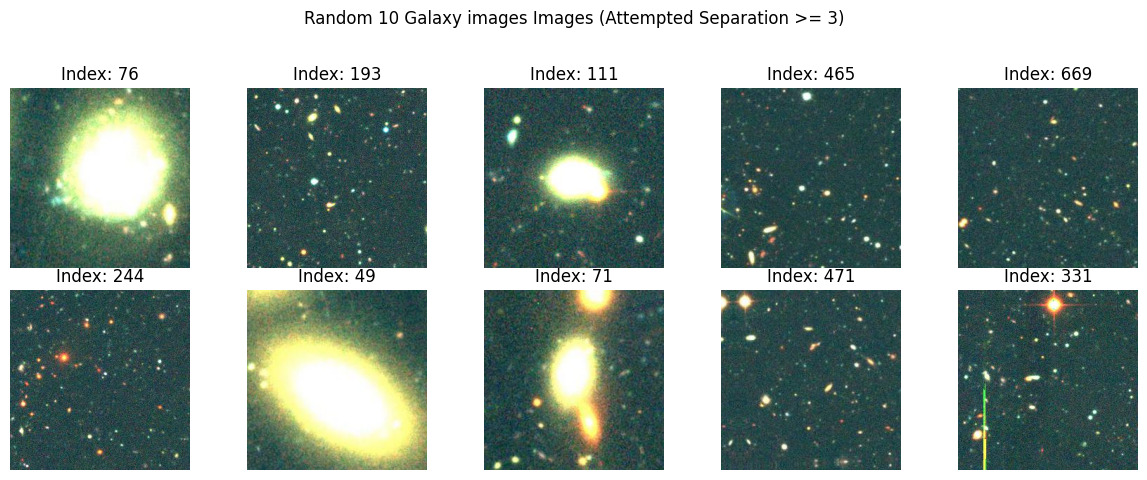

In [6]:
plot_random_images(galaxies_images/255, num_to_plot=10, min_separation=3, title_prefix="Galaxy images")

In [5]:
blue_blob_data_array_float = image_to_float("blue_blob_train_images_new")*255
blue_blob_val_data_array_float = image_to_float("blueblobs_val")*255

Attempting to load JPEG images from: blue_blob_train_images_new using TensorFlow/Keras
Expecting images of size: (256, 256)
Found 600 items in the directory. Processing valid JPEGs...

------------------------------------
Image loading successful!
Loaded 600 images.
Final NumPy array shape: (600, 256, 256, 3)
Data type of array elements: uint8
------------------------------------
Attempting to load JPEG images from: blueblobs_val using TensorFlow/Keras
Expecting images of size: (256, 256)
Found 241 items in the directory. Processing valid JPEGs...

------------------------------------
Image loading successful!
Loaded 241 images.
Final NumPy array shape: (241, 256, 256, 3)
Data type of array elements: uint8
------------------------------------


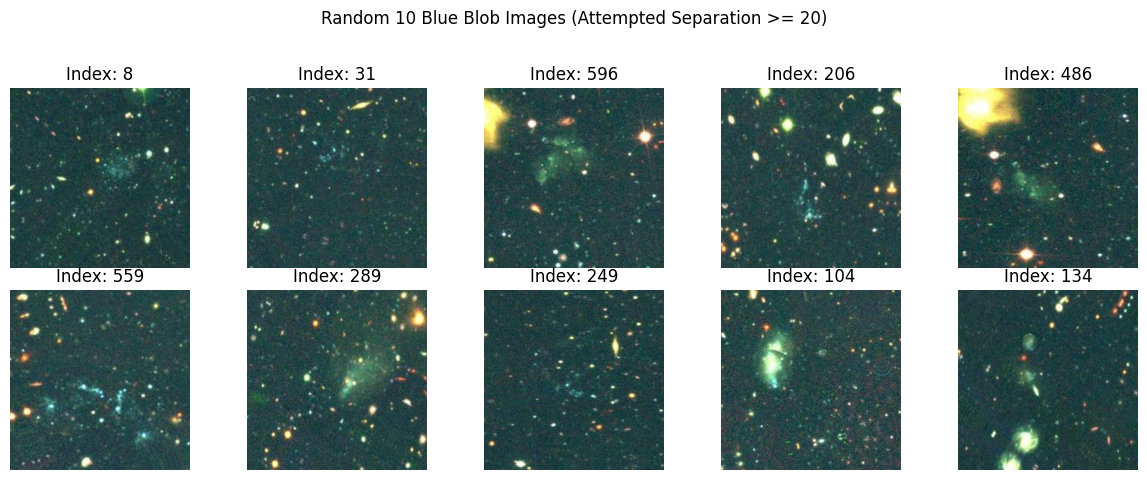

In [8]:
plot_random_images(blue_blob_data_array_float/255, num_to_plot=10, min_separation=20, title_prefix="Blue Blob")

In [6]:
devices = tf.config.list_physical_devices()
print("\nDevices: ", devices)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
  details = tf.config.experimental.get_device_details(gpus[0])
  print("GPU details: ", details)


Devices:  [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU details:  {'device_name': 'METAL'}


In [7]:
indices = np.arange(galaxies_images.shape[0]+ blue_blob_data_array_float.shape[0])

# Shuffle the indices randomly IN-PLACE
np.random.shuffle(indices)

In [8]:
galaxy_train_labels = np.ones(galaxies_images.shape[0], dtype=np.int64)
blue_blob_train_labels = np.zeros(blue_blob_data_array_float.shape[0], dtype=np.int64)
X_train = np.concatenate((galaxies_images, blue_blob_data_array_float), axis=0)
y_train = np.concatenate((galaxy_train_labels, blue_blob_train_labels), axis=0)
X_train = X_train[indices]
y_train = y_train[indices]

In [9]:
indices = np.arange(galaxies_val_images.shape[0]+ blue_blob_val_data_array_float.shape[0])

# Shuffle the indices randomly IN-PLACE
np.random.shuffle(indices)

In [10]:
galaxy_val_labels = np.ones(galaxies_val_images.shape[0], dtype=np.int64)
blue_blob_val_labels = np.zeros(blue_blob_val_data_array_float.shape[0], dtype=np.int64)
X_val = np.concatenate((galaxies_val_images, blue_blob_val_data_array_float), axis=0)
y_val = np.concatenate((galaxy_val_labels, blue_blob_val_labels), axis=0)
X_val = X_val[indices]
y_val = y_val[indices]

In [11]:

print("Finished splitting.")
print(f"Training images shape:   {X_train.shape}") # e.g., (6493, 256, 256, 3)
print(f"Training labels shape:   {y_train.shape}") # e.g., (6493,)
print(f"Validation images shape: {X_val.shape}")   # e.g., (1623, 256, 256, 3)
print(f"Validation labels shape: {y_val.shape}")   # e.g., (1623,)


Finished splitting.
Training images shape:   (1280, 256, 256, 3)
Training labels shape:   (1280,)
Validation images shape: (547, 256, 256, 3)
Validation labels shape: (547,)


In [12]:
train_blob_percent = (np.sum(y_train == 0) / len(y_train)) * 100
val_blob_percent = (np.sum(y_val == 0) / len(y_val)) * 100
print(f"Percentage of blobs in training set:   {train_blob_percent:.2f}%")
print(f"Percentage of blobs in validation set: {val_blob_percent:.2f}%")
# These percentages should be very close to each other and to the overall percentage in all_labels_shuffled

Percentage of blobs in training set:   46.88%
Percentage of blobs in validation set: 44.06%


In [13]:
IMG_SIZE = 256  # Should match the size of images in X_train, X_val (which is 256)
N_CLASSES = 1   # Single output neuron for binary classification with sigmoid
BATCH_SIZE = 32
INITIAL_EPOCHS = 15 # Epochs for training the head
FINETUNE_EPOCHS = 20 # Epochs for fine-tuning (Adjust as needed)
INITIAL_LR = 1e-4 # Learning rate for head training (maybe slightly lower than default)
FINETUNE_LR = 1e-5 # Learning rate for fine-tuning


In [14]:
def preprocess_data_resnet(X):
    """trains a convolutional neural network to classify the dataset"""
    X_p = resnet_preprocess_input(X)
    return X_p



In [15]:
X_copy = np.copy(X_train)
X_val_copy = np.copy(X_val)
X_train_resnet = preprocess_data_resnet(X_copy)
X_val_resnet = preprocess_data_resnet(X_val_copy)
print(f"Preprocessed training images shape:   {X_train.shape}") # e.g., (6493, 256, 256, 3)
print(f"Preprocessed training labels shape:   {y_train.shape}") # e.g., (6493,)
print(f"Preprocessed validation images shape: {X_val.shape}")   # e.g., (1623, 256, 256, 3)
print(f"Preprocessed validation labels shape: {y_val.shape}")   # e.g., (1623,)

Preprocessed training images shape:   (1280, 256, 256, 3)
Preprocessed training labels shape:   (1280,)
Preprocessed validation images shape: (547, 256, 256, 3)
Preprocessed validation labels shape: (547,)


## Using ResNet50V2


In [16]:
X_train_resnet.min(), X_train_resnet.max(), X_train_resnet.mean(), X_train_resnet.std()

(-1.0, 1.0, -0.45328063, 0.31361178)

In [18]:

# --- 2. Build Model ---
IMG_SHAPE = (IMG_SIZE, IMG_SIZE, 3)
inputs = Input(shape=IMG_SHAPE)
# Use ResNet50V2 as the base model
base_model = ResNet50V2(
    include_top=False,
    weights="imagenet",
    input_shape=IMG_SHAPE,
    pooling="avg"
)
base_model.trainable = False  # freeze initially

x = base_model(inputs, training=False)
# Add a dropout layer
x = Dropout(0.2)(x)
# Add a fully connected layer
x = Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001))(x)
# Add another dropout layer
x = Dropout(0.1)(x)
outputs = Dense(N_CLASSES, activation='sigmoid')(x)

model = Model(inputs, outputs, name="Blob_Galaxy_Classifier")
model.summary()

# --- 3. Calculate Class Weights ---
class_labels = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=class_labels,
    y=y_train
)
class_weights_dict = {i: class_weights[i] for i in range(len(class_labels))}
print(f"Class weights: {class_weights_dict}")


# --- 4. Compile Model ---
INITIAL_LR = 1e-4  # Make sure it's defined
model.compile(
    optimizer=AdamW(learning_rate=INITIAL_LR),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name='precision_gal', thresholds=0.5),
        keras.metrics.Recall(name='recall_gal', thresholds=0.5),
        keras.metrics.AUC(name='auc')
    ]
)

# 3) Your original fit, plus our new callback
history_head = model.fit(
    X_train_resnet,
    y_train,
    batch_size=32,
    epochs=23,
    validation_data=(X_val_resnet, y_val),
    class_weight=class_weights_dict,
    shuffle=True,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=4,
            mode='min',
            restore_best_weights=True,
            verbose=1
        ),
        # save every epoch if you still want the full history
        keras.callbacks.ModelCheckpoint(
            "resnet_50V2_mlp/epoch_{epoch:02d}.keras",
            save_freq="epoch"
        ),
    ]
)



Model: "Blob_Galaxy_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 2048)           │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,827,201 (90.89 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,564,800 (89.89 MB)

Class weights: {0: 1.0666666666666667, 1: 0.9411764705882353}
Epoch 1/23


2025-05-06 00:07:40.095295: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 417ms/step - accuracy: 0.6290 - auc: 0.6434 - loss: 0.9112 - precision_gal: 0.6498 - recall_gal: 0.7100 - val_accuracy: 0.9488 - val_auc: 0.9955 - val_loss: 0.5486 - val_precision_gal: 0.9264 - val_recall_gal: 0.9869
Epoch 2/23
40/40 ━━━━━━━━━━━━━━━━━━━━ 14s 352ms/step - accuracy: 0.8272 - auc: 0.9041 - loss: 0.6370 - precision_gal: 0.8607 - recall_gal: 0.8146 - val_accuracy: 0.9616 - val_auc: 0.9975 - val_loss: 0.4260 - val_precision_gal: 0.9412 - val_recall_gal: 0.9935
Epoch 3/23
40/40 ━━━━━━━━━━━━━━━━━━━━ 14s 353ms/step - accuracy: 0.8965 - auc: 0.9597 - loss: 0.5064 - precision_gal: 0.9255 - recall_gal: 0.8825 - val_accuracy: 0.9616 - val_auc: 0.9977 - val_loss: 0.3594 - val_precision_gal: 0.9412 - val_recall_gal: 0.9935
Epoch 4/23
40/40 ━━━━━━━━━━━━━━━━━━━━ 14s 355ms/step - accuracy: 0.9177 - auc: 0.9769 - loss: 0.4382 - precision_gal: 0.9713 - recall_gal: 0.8678 - val_accuracy: 0.9488 - val_auc: 0.9973 - val_loss: 0.3287 - val_precision_gal: 0.9212 

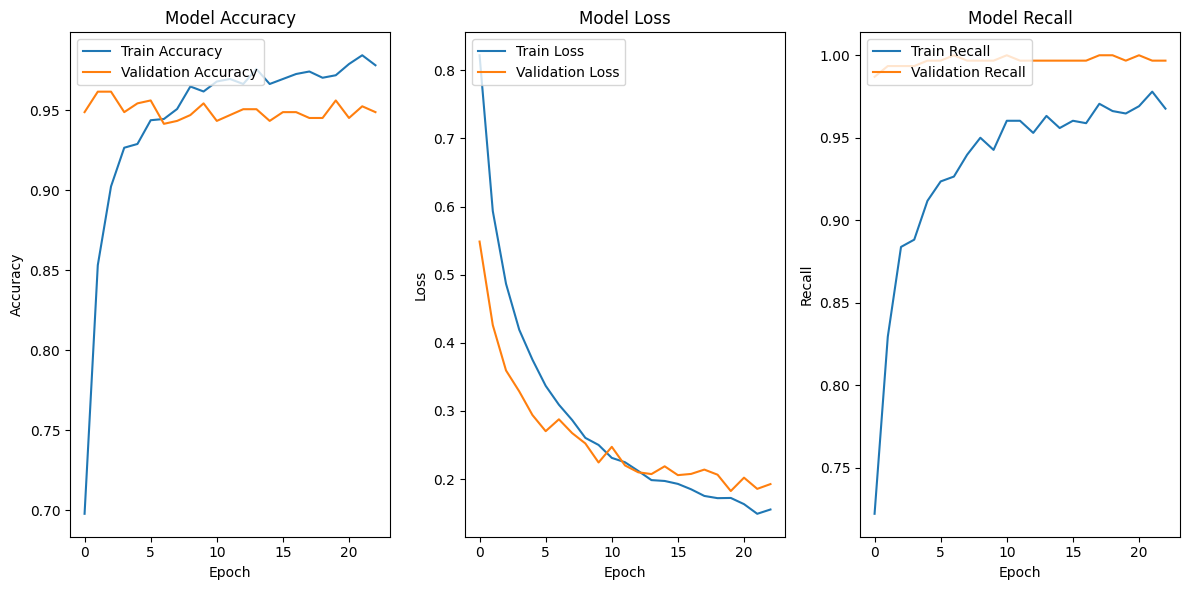

In [19]:

# --- 5. Plot Training History ---
def plot_training_history(history):
    # Plot training & validation accuracy values
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 3, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(loc='upper left')

    # Plot training & validation loss values
    plt.subplot(1, 3, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(loc='upper left')

    plt.subplot(1, 3, 3)
    plt.plot(history.history['recall_gal'], label='Train Recall')
    plt.plot(history.history['val_recall_gal'], label='Validation Recall')
    plt.title('Model Recall')
    plt.ylabel('Recall')
    plt.xlabel('Epoch')
    plt.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

plot_training_history(history_head)


18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 378ms/step
Predicted classes shape: (547, 1), dtype: int64


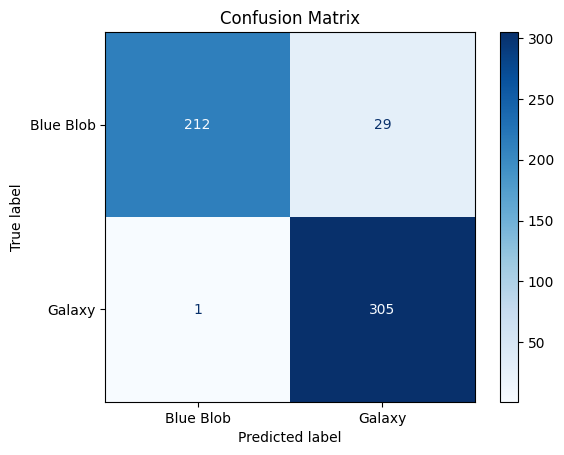

              precision    recall  f1-score   support

   Blue Blob       1.00      0.88      0.93       241
      Galaxy       0.91      1.00      0.95       306

    accuracy                           0.95       547
   macro avg       0.95      0.94      0.94       547
weighted avg       0.95      0.95      0.94       547



In [94]:
# test the model on validation set
y_pred = model.predict(X_val_resnet)
y_pred_classes = np.where(y_pred > 0.5, 1, 0) # Convert probabilities to binary predictions
print(f"Predicted classes shape: {y_pred_classes.shape}, dtype: {y_pred_classes.dtype}")


# --- 6. Evaluate Model ---
# Calculate confusion matrix
cm = confusion_matrix(y_val, y_pred_classes)
# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Blue Blob', 'Galaxy'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()
# Print classification report
print(classification_report(y_val, y_pred_classes, target_names=['Blue Blob', 'Galaxy']))

In [96]:
tf.keras.models.save_model(model,"final_models/blue_blob_galaxy_resnet_50V2_mlp.keras")

In [19]:
model = keras.models.load_model('blue_blob_galaxy_classifier.keras')

/opt/anaconda3/envs/blue_blob_GenAI/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 6 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## No head ResNet50V2

Final Class Weights: {0: 1.0666666666666667, 1: 0.9411764705882353}

--- Training Classifier Head (Binary) ---
Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 24s 480ms/step - accuracy: 0.4982 - auc: 0.5835 - loss: 0.7455 - precision_gal: 0.8430 - recall_gal: 0.1111 - val_accuracy: 0.6892 - val_auc: 0.7624 - val_loss: 0.6329 - val_precision_gal: 0.7698 - val_recall_gal: 0.6340 - learning_rate: 1.0000e-04
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 14s 354ms/step - accuracy: 0.6757 - auc: 0.7495 - loss: 0.6325 - precision_gal: 0.7185 - recall_gal: 0.6657 - val_accuracy: 0.8135 - val_auc: 0.8873 - val_loss: 0.5684 - val_precision_gal: 0.8566 - val_recall_gal: 0.8007 - learning_rate: 1.0000e-04
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 14s 363ms/step - accuracy: 0.7903 - auc: 0.8606 - loss: 0.5860 - precision_gal: 0.8442 - recall_gal: 0.7434 - val_accuracy: 0.8702 - val_auc: 0.9395 - val_loss: 0.5181 - val_precision_gal: 0.8930 - val_recall_gal: 0.8725 - learning_rate: 1.0000e-04
Epoch 4/20
40/40 ━━━━━━━━━━━

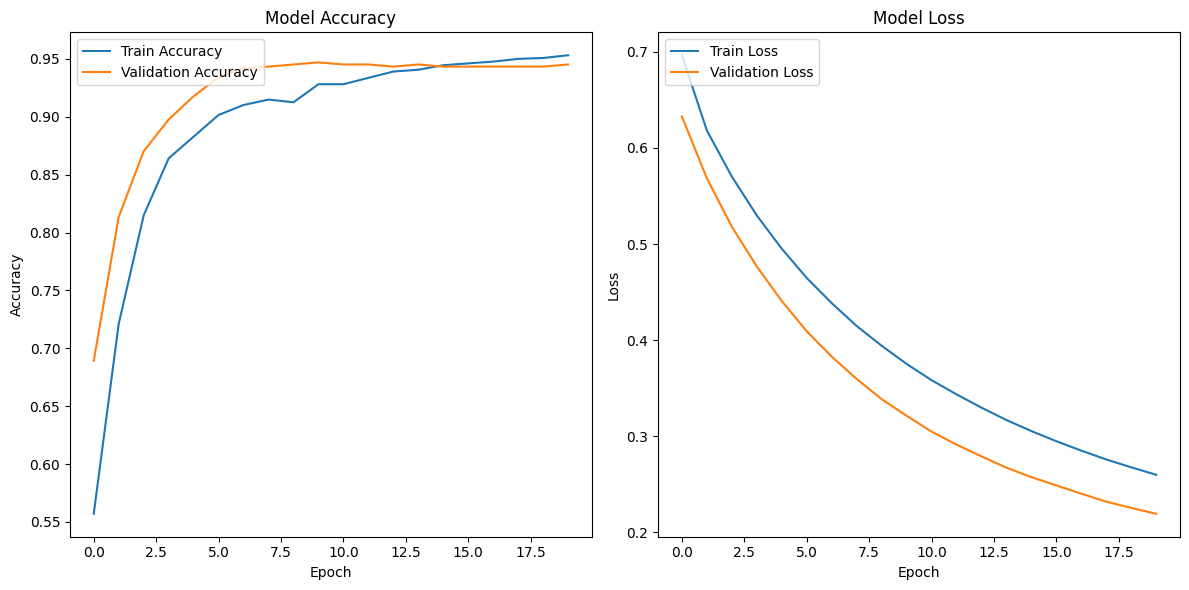

In [20]:

# --- 2. Build Model ---
IMG_SHAPE = (IMG_SIZE, IMG_SIZE, 3)
inputs = Input(shape=IMG_SHAPE)

# 1. Load the ResNet backbone WITHOUT its top classifier
backbone = ResNet50V2(
    include_top=False,
    weights="imagenet",
    input_shape=IMG_SHAPE,
)

# 2. Grab the last conv feature-maps
x = backbone(inputs, training = False)  # shape (None, h, w, c)

# 3. Pool them to a vector
x = GlobalAveragePooling2D(name="gap")(x)

# 5. Your new head: one sigmoid unit
outputs = Dense(
    1,
    activation="sigmoid",
    kernel_regularizer=keras.regularizers.l2(0.001),
    name="classifier"
)(x)

# 6. Build the new model
model_resnet_simpler = Model(inputs=inputs, outputs=outputs, name="ResNet50V2_binary")

# 7. Freeze the backbone if you like
backbone.trainable = False
# --- 3. Calculate Class Weights ---
class_labels = np.unique(y_train)
weights = compute_class_weight('balanced', classes=class_labels, y=y_train)
class_weight_dict = dict(zip(class_labels, weights))


print(f"Final Class Weights: {class_weight_dict}")

# --- 4. Compile Model ---
INITIAL_LR = 1e-4  # Make sure it's defined
model_resnet_simpler.compile(
    optimizer=AdamW(learning_rate=INITIAL_LR),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name='precision_gal', thresholds=0.5),
        keras.metrics.Recall(name='recall_gal', thresholds=0.5),
        keras.metrics.AUC(name='auc')
    ]
)

# --- 5. Train Head ---
print("\n--- Training Classifier Head (Binary) ---")
history_head = model_resnet_simpler.fit(
    X_train_resnet,
    y_train,
    batch_size=32,
    epochs=20,
    validation_data=(X_val_resnet, y_val),
    class_weight=class_weight_dict,
    shuffle=True,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, mode='min', restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)  # Reduce LR on plateau
    ]
)


print("\n--- Head training complete. Best weights restored based on val_recall_blob ---")
# --- 5. Plot Training History ---
def plot_training_history(history):
    # Plot training & validation accuracy values
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(loc='upper left')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

plot_training_history(history_head)


In [21]:
tf.keras.models.save_model(model_resnet_simpler,"final_models/blue_blob_galaxy_ResNet50V2_nohead.keras")

## EffecientNet



Using the following data:
X_train shape: (1280, 256, 256, 3), dtype: float32
y_train shape: (1280,), dtype: int64
X_val shape:   (547, 256, 256, 3), dtype: float32
y_val shape:   (547,), dtype: int64


2025-05-04 22:27:54.686072: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2025-05-04 22:27:54.686202: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-05-04 22:27:54.686206: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-05-04 22:27:54.686236: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-05-04 22:27:54.686258: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Final Class Weights: {0: 1.0666666666666667, 1: 0.9411764705882353}


Model: "EffecientNet_binary_resized"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 8, 8, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       196,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

 Trainable params: 196,865 (769.00 KB)

 Non-trainable params: 10,783,535 (41.14 MB)


--- Training Classifier Head (Binary) ---
Epoch 1/20


2025-05-04 22:27:59.008448: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


40/40 ━━━━━━━━━━━━━━━━━━━━ 34s 700ms/step - accuracy: 0.6489 - auc: 0.7069 - loss: 0.6274 - precision_gal: 0.7125 - recall_gal: 0.5551 - val_accuracy: 0.8995 - val_auc: 0.9617 - val_loss: 0.4351 - val_precision_gal: 0.8792 - val_recall_gal: 0.9510
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 23s 567ms/step - accuracy: 0.8690 - auc: 0.9539 - loss: 0.3976 - precision_gal: 0.9131 - recall_gal: 0.8290 - val_accuracy: 0.8793 - val_auc: 0.9734 - val_loss: 0.3452 - val_precision_gal: 0.8352 - val_recall_gal: 0.9771
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 23s 568ms/step - accuracy: 0.9330 - auc: 0.9872 - loss: 0.2620 - precision_gal: 0.9617 - recall_gal: 0.9091 - val_accuracy: 0.8848 - val_auc: 0.9779 - val_loss: 0.3032 - val_precision_gal: 0.8403 - val_recall_gal: 0.9804
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 23s 567ms/step - accuracy: 0.9561 - auc: 0.9908 - loss: 0.2078 - precision_gal: 0.9687 - recall_gal: 0.9458 - val_accuracy: 0.8702 - val_auc: 0.9838 - val_loss: 0.3078 - val_precision_gal: 0.8150 

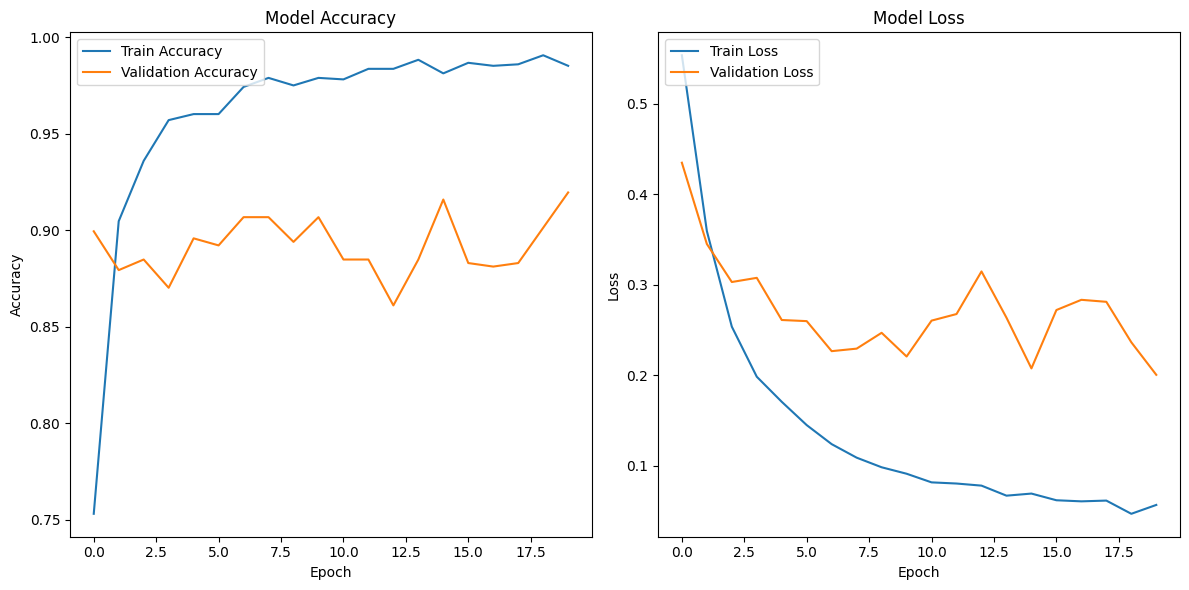

In [16]:


# --- Verify Shapes and Types (Good practice) ---
print("Using the following data:")
print(f"X_train shape: {X_train.shape}, dtype: {X_train.dtype}")
print(f"y_train shape: {y_train.shape}, dtype: {y_train.dtype}")
print(f"X_val shape:   {X_val.shape}, dtype: {X_val.dtype}")
print(f"y_val shape:   {y_val.shape}, dtype: {y_val.dtype}")

# --- Define Constants ---
IMG_SIZE = 256 # Your original size
TARGET_SIZE = 300 # The size EfficientNetB3 was trained on

# --- 2. Build Model ---
# Input shape still reflects the original data size
INPUT_SHAPE = (IMG_SIZE, IMG_SIZE, 3)
# Target shape for the base model
BASE_MODEL_SHAPE = (TARGET_SIZE, TARGET_SIZE, 3)

# Define the input layer with the original image shape
inputs = keras.Input(shape=INPUT_SHAPE)

"""# Add a Resizing layer right after the input
x = Resizing(
    height=TARGET_SIZE,
    width=TARGET_SIZE,
    interpolation="bilinear" # Common interpolation method
)(inputs)"""

# 1. Load the EfficientNet backbone WITHOUT its top classifier
#    Instantiate it expecting the TARGET_SIZE input
base_model = EfficientNetB3(
    include_top=False,
    weights="imagenet",
    input_shape=INPUT_SHAPE, # IMPORTANT: Set this to the target size
)

# 7. Freeze the backbone
base_model.trainable = False

# 2. Pass the *resized* inputs through the base model
x = base_model(inputs, training=False)  # shape (None, h', w', c) based on 300x300 input

# Add the classifier head
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.2)(x)  # Optional: Add dropout for regularization
outputs = Dense(1, activation="sigmoid",
    kernel_regularizer=keras.regularizers.l2(0.001),
    name="classifier")(x)

# 6. Build the new model
model_effecient_one_layer = Model(inputs=inputs, outputs=outputs, name="EffecientNet_binary_resized")

# --- 3. Calculate Class Weights ---
# Dummy data for placeholder - replace with your actual y_train
# y_train = np.random.randint(0, 2, size=100) # Example placeholder
# Ensure y_train is defined before this step in your actual script
class_labels = np.unique(y_train)
weights = compute_class_weight('balanced', classes=class_labels, y=y_train)
class_weight_dict = dict(zip(class_labels, weights))

print(f"Final Class Weights: {class_weight_dict}")

# --- 4. Compile Model ---
# Using the increased LR and updated EarlyStopping monitor from previous suggestions
INITIAL_LR = 1e-4
model_effecient_one_layer.compile(
    optimizer=AdamW(learning_rate=INITIAL_LR),
    loss=keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=[
        "accuracy",
        keras.metrics.Precision(name='precision_gal', thresholds=0.5),
        keras.metrics.Recall(name='recall_gal', thresholds=0.5),
        keras.metrics.AUC(name='auc')
    ]
)
# Display model summary to verify shapes
model_effecient_one_layer.summary()

# --- 5. Train Head ---
print("\n--- Training Classifier Head (Binary) ---")
history_head = model_effecient_one_layer.fit(
    X_train, # Still provide the original sized (256x256), preprocessed data
    y_train,
    batch_size=32,
    epochs=20,
    validation_data=(X_val, y_val), # Still provide the original sized (256x256), preprocessed data
    class_weight=class_weight_dict,
    shuffle=True,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=6,
            mode='min',
            restore_best_weights=True,
            verbose=1
        ),
        # save every epoch if you still want the full history
        keras.callbacks.ModelCheckpoint(
            "EffecientNet_mlp/epoch_{epoch:02d}.keras",
            save_freq="epoch"
        ),
    ]
)


print("\nTraining finished.")

print("\n--- Head training complete. Best weights restored based on val_recall_gal ---")
# --- 5. Plot Training History ---
def plot_training_history(history):
    # Plot training & validation accuracy values
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(loc='upper left')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

plot_training_history(history_head)


18/18 ━━━━━━━━━━━━━━━━━━━━ 13s 596ms/step
Predicted classes shape: (547, 1), dtype: int64


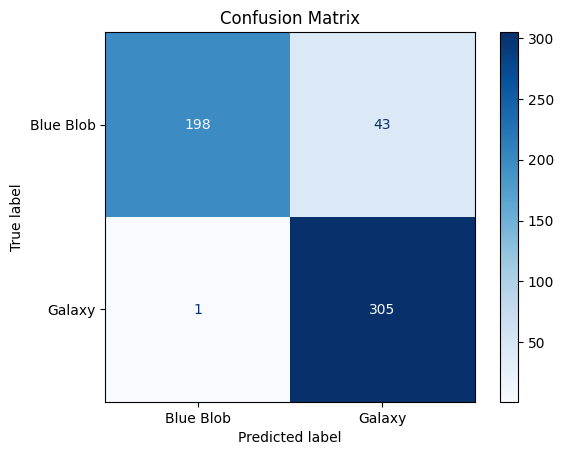

              precision    recall  f1-score   support

   Blue Blob       0.99      0.82      0.90       241
      Galaxy       0.88      1.00      0.93       306

    accuracy                           0.92       547
   macro avg       0.94      0.91      0.92       547
weighted avg       0.93      0.92      0.92       547



In [17]:
# test the model on validation set
y_pred = model_effecient_one_layer.predict(X_val)
y_pred_classes = np.where(y_pred > 0.5, 1, 0) # Convert probabilities to binary predictions
print(f"Predicted classes shape: {y_pred_classes.shape}, dtype: {y_pred_classes.dtype}")


# --- 6. Evaluate Model ---
# Calculate confusion matrix
cm = confusion_matrix(y_val, y_pred_classes)
# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Blue Blob', 'Galaxy'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()
# Print classification report
print(classification_report(y_val, y_pred_classes, target_names=['Blue Blob', 'Galaxy']))

In [ ]:
tf.keras.models.save_model(model_effecient_one_layer,"final_models/blue_blob_galaxy_efficientB3_mlp.keras")

: 

## Big model

Final Class Weights: {0: 1.0666666666666667, 1: 0.9411764705882353}

--- Training Classifier Head (Binary) ---
Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 48s 925ms/step - accuracy: 0.5689 - auc: 0.5883 - loss: 1.4190 - precision_gal: 0.6141 - recall_gal: 0.5500 - val_accuracy: 0.6033 - val_auc: 0.9956 - val_loss: 1.2383 - val_precision_gal: 0.5851 - val_recall_gal: 1.0000
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 28s 699ms/step - accuracy: 0.8734 - auc: 0.9474 - loss: 0.8906 - precision_gal: 0.9469 - recall_gal: 0.8172 - val_accuracy: 0.7422 - val_auc: 0.9979 - val_loss: 1.0147 - val_precision_gal: 0.6846 - val_recall_gal: 1.0000
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 32s 789ms/step - accuracy: 0.9297 - auc: 0.9857 - loss: 0.7339 - precision_gal: 0.9831 - recall_gal: 0.8833 - val_accuracy: 0.8446 - val_auc: 0.9982 - val_loss: 0.8545 - val_precision_gal: 0.7826 - val_recall_gal: 1.0000
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.9414 - auc: 0.9928 - loss: 0.6791 - precision_ga

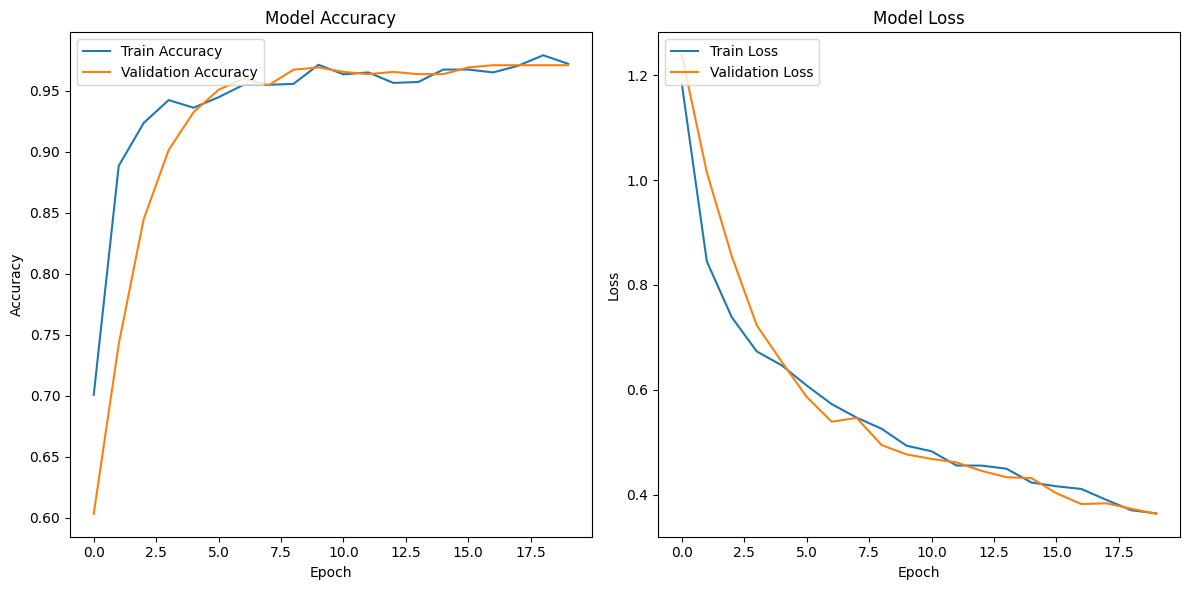

In [24]:


# --- 2. Build Model ---
IMG_SHAPE = (IMG_SIZE, IMG_SIZE, 3)
inputs = Input(shape=IMG_SHAPE)



# 1. Load the ResNet backbone WITHOUT its top classifier
base_model = ResNet101V2(
    include_top=False,
    weights="imagenet",
    input_shape=IMG_SHAPE,
    pooling="avg"
)
base_model.trainable = False

# 2. Neck + head
x = base_model(inputs, training=False)
x = Dropout(0.2)(x)

# smaller first dense → BN → dropout
x = Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001))(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

# second dense → BN
x = Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001))(x)
x = BatchNormalization()(x)

# final output
outputs = Dense(N_CLASSES, activation='sigmoid')(x)

# 6. Build the new model
model_resnet_101 = Model(inputs=inputs, outputs=outputs, name="ResNet101_binary")

# 7. Freeze the backbone if you like
backbone.trainable = False
# --- 3. Calculate Class Weights ---
class_labels = np.unique(y_train)
weights = compute_class_weight('balanced', classes=class_labels, y=y_train)
class_weight_dict = dict(zip(class_labels, weights))


print(f"Final Class Weights: {class_weight_dict}")

# --- 4. Compile Model ---
INITIAL_LR = 1e-4  # Make sure it's defined
model_resnet_101.compile(
    optimizer=AdamW(learning_rate=INITIAL_LR),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name='precision_gal', thresholds=0.5),
        keras.metrics.Recall(name='recall_gal', thresholds=0.5),
        keras.metrics.AUC(name='auc')
    ]
)



# --- 5. Train Head ---
print("\n--- Training Classifier Head (Binary) ---")
history_head = model_resnet_101.fit(
    X_train_resnet,
    y_train,
    batch_size=32,
    epochs=20,
    validation_data=(X_val_resnet, y_val),
    class_weight=class_weight_dict,
    shuffle=True,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=4,
            mode='min',
            restore_best_weights=True,
            verbose=1
        ),
        # save every epoch if you still want the full history
        keras.callbacks.ModelCheckpoint(
            "resnet101/epoch_{epoch:02d}.keras",
            save_freq="epoch"
        ),
    ]
)


print("\n--- Head training complete. Best weights restored based on val_recall_blob ---")
# --- 5. Plot Training History ---
def plot_training_history(history):
    # Plot training & validation accuracy values
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(loc='upper left')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

plot_training_history(history_head)


18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 579ms/step
Predicted classes shape: (547, 1), dtype: int64


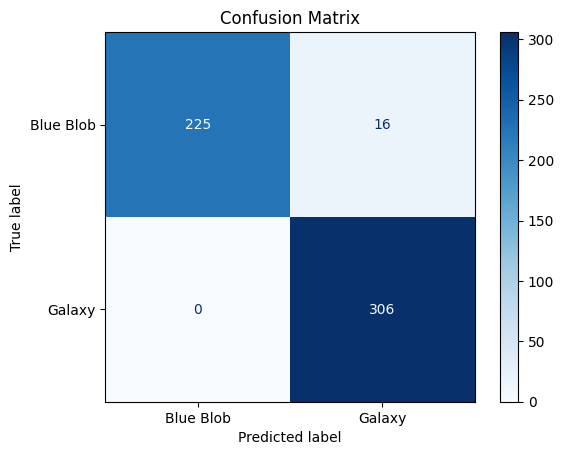

              precision    recall  f1-score   support

   Blue Blob       1.00      0.93      0.97       241
      Galaxy       0.95      1.00      0.97       306

    accuracy                           0.97       547
   macro avg       0.98      0.97      0.97       547
weighted avg       0.97      0.97      0.97       547



In [25]:
# test the model on validation set
y_pred = model_resnet_101.predict(X_val_resnet)
y_pred_classes = np.where(y_pred > 0.5, 1, 0) # Convert probabilities to binary predictions
print(f"Predicted classes shape: {y_pred_classes.shape}, dtype: {y_pred_classes.dtype}")


# --- 6. Evaluate Model ---
# Calculate confusion matrix
cm = confusion_matrix(y_val, y_pred_classes)
# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Blue Blob', 'Galaxy'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()
# Print classification report
print(classification_report(y_val, y_pred_classes, target_names=['Blue Blob', 'Galaxy']))

In [ ]:
tf.keras.models.save_model(model_resnet_101,"final_models/blue_blob_galaxy_resnet_101V2.keras")

: 